In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


In [ ]:
!pip install kagglehub --quiet

In [ ]:
import kagglehub
kagglehub.login()

In [ ]:
import kagglehub
path = kagglehub.competition_download('playground-series-s4e4')
print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/playground-series-s4e4


In [ ]:
import os

print(os.listdir(path))

train = pd.read_csv(os.path.join(path, 'train.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(path, 'sample_submission.csv'))

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
train.head()

['sample_submission.csv', 'train.csv', 'test.csv']
Train shape: (90615, 10)
Test shape: (60411, 9)


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [ ]:
train.info()
print('\n' + '='*50)
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB



,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,45307.000000,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,26158.441658,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,22653.500000,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,45307.000000,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,67960.500000,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,90614.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
df.dropna

In [ ]:
train.describe(include='object')

,Sex
count,90615
unique,3
top,I
freq,33093


In [ ]:
print('Null values in train:')
print(train.isnull().sum())
print('\nNull values in test:')
print(test.isnull().sum())

print(f'\nDuplicated rows in train: {train.duplicated().sum()}')
print(f'Duplicated rows in test: {test.duplicated().sum()}')

Null values in train:
id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

Null values in test:
id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
dtype: int64

Duplicated rows in train: 0
Duplicated rows in test: 0


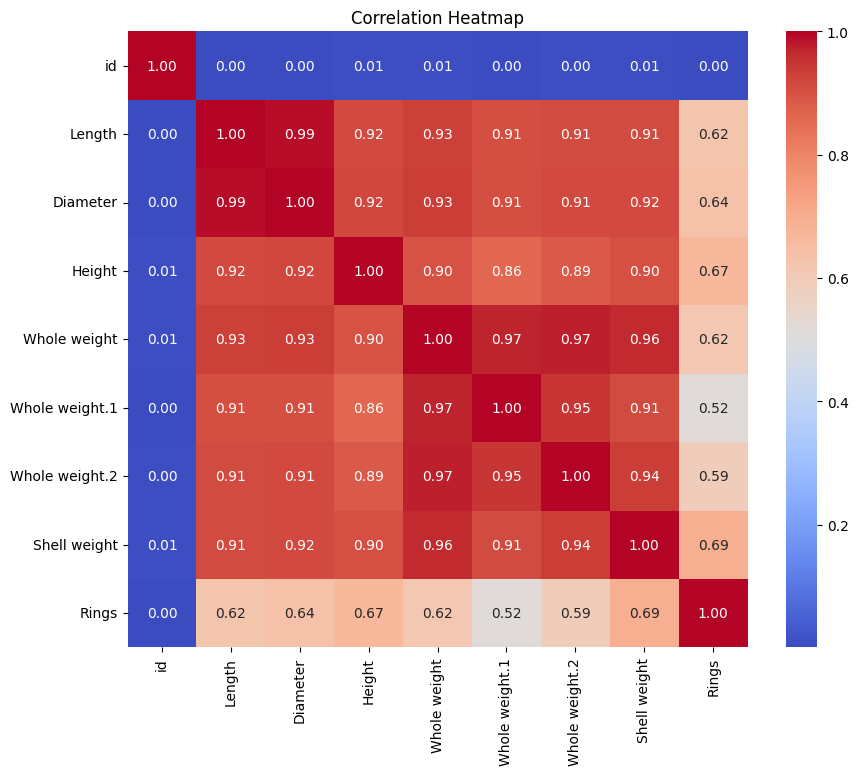

In [ ]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

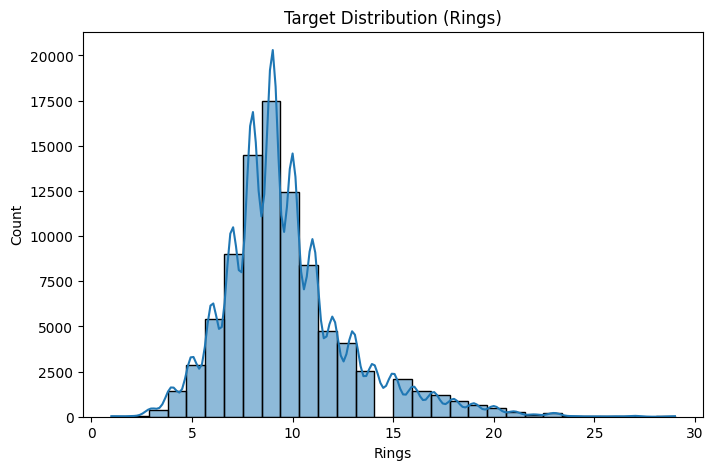

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(train['Rings'], bins=30, kde=True)
plt.title('Target Distribution (Rings)')
plt.show()

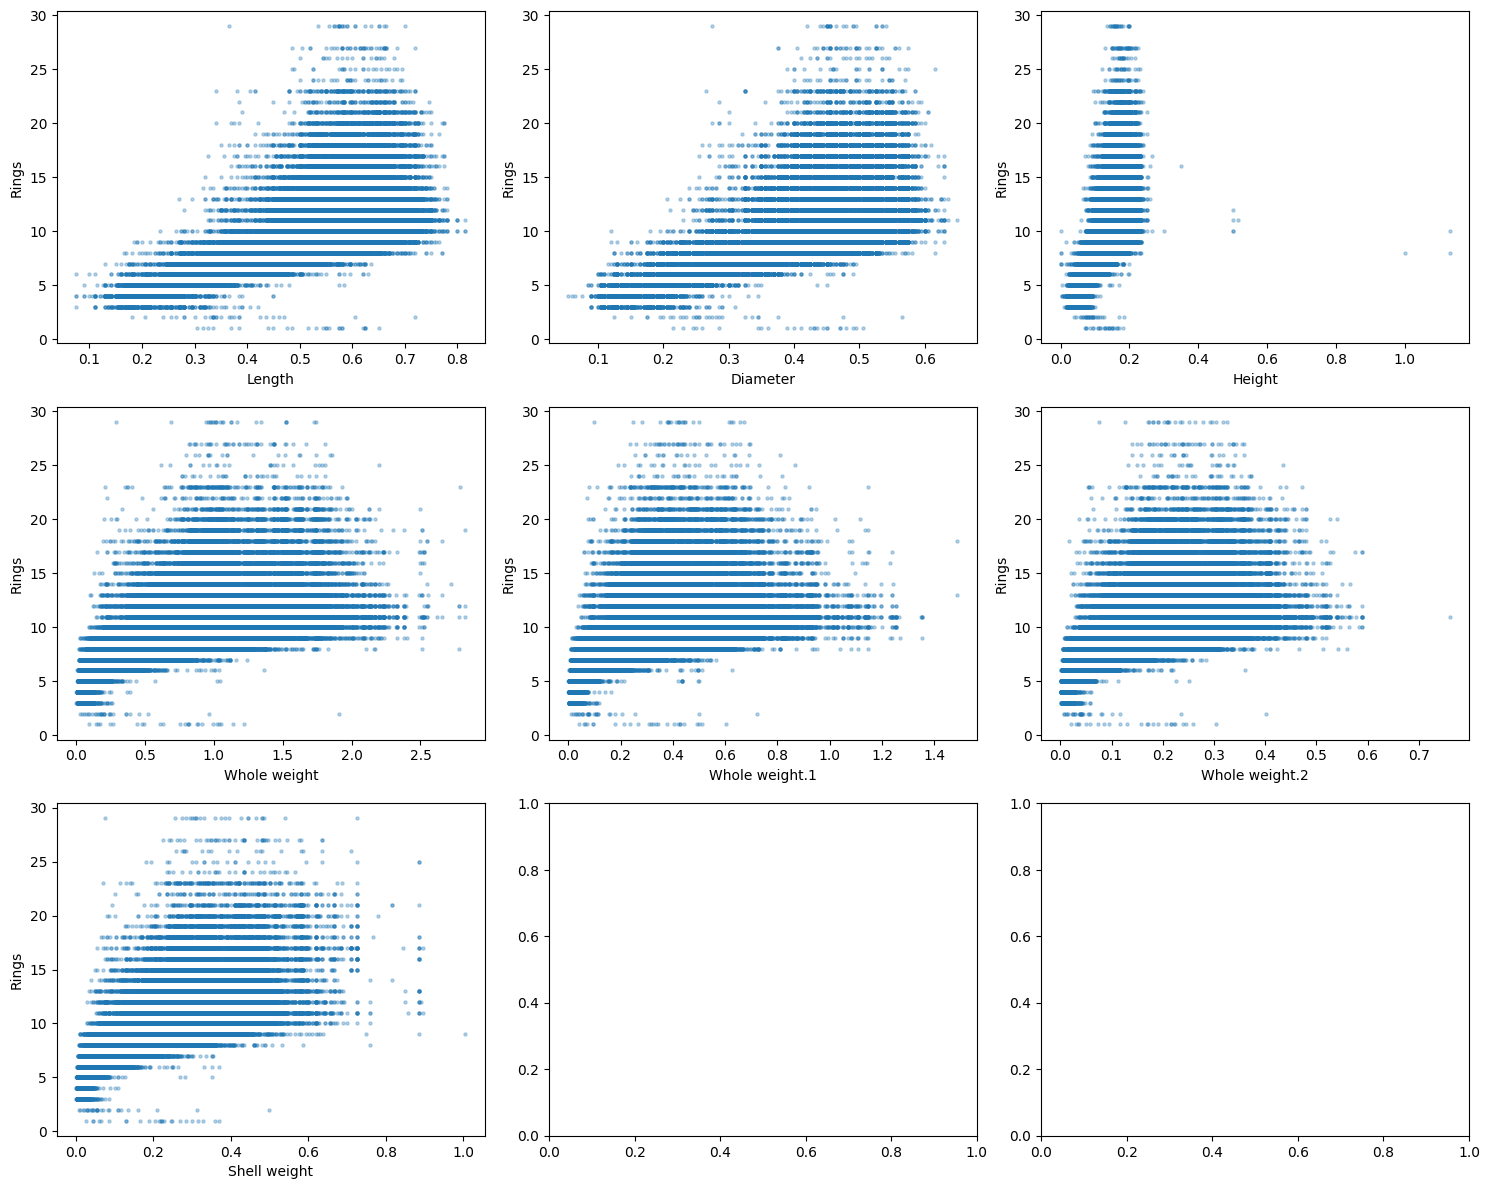

In [ ]:
features_to_plot = ['Length', 'Diameter', 'Height', 'Whole weight',
                     'Whole weight.1', 'Whole weight.2', 'Shell weight']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    axes[i].scatter(train[col], train['Rings'], alpha=0.3, s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Rings')
plt.tight_layout()
plt.show()

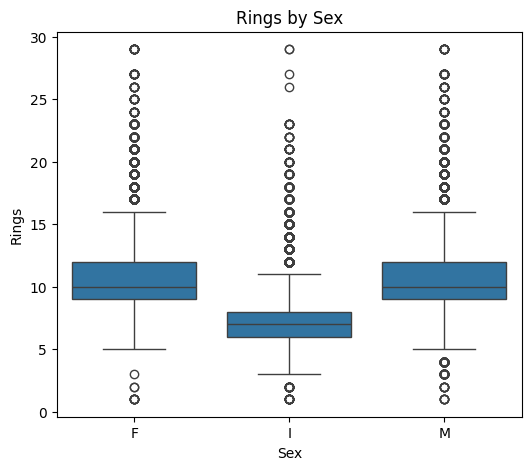

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Sex', y='Rings', data=train)
plt.title('Rings by Sex')
plt.show()

In [ ]:
features = ['Sex', 'Length', 'Diameter', 'Height',
            'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight']
target = 'Rings'

X = train[features].copy()
y = train[target].copy()
X_test_final = test[features].copy()

print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (90615, 8), y shape: (90615,)


In [ ]:
le = LabelEncoder()
le.fit(pd.concat([X['Sex'], X_test_final['Sex']]))

X['Sex'] = le.transform(X['Sex'])
X_test_final['Sex'] = le.transform(X_test_final['Sex'])

print('Sex classes:', le.classes_)
X.head()

Sex classes: ['F' 'I' 'M']


,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,0,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400
1,0,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200
2,1,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050
3,2,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500
4,1,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'y_train: {y_train.shape}, y_val: {y_val.shape}')

X_train: (72492, 8), X_val: (18123, 8)
y_train: (72492,), y_val: (18123,)


In [ ]:
numeric_features = ['Length', 'Diameter', 'Height', 'Whole weight',
                     'Whole weight.1', 'Whole weight.2', 'Shell weight']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test_final.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_final[numeric_features])

X_train_scaled.head()

,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
43718,2,1.125265,1.055134,1.037589,1.303539,1.809351,1.316374,1.030331
45247,0,1.294627,1.208318,1.562869,1.643625,1.449565,1.748091,1.222442
71393,2,0.744199,0.953011,0.380989,0.755682,1.065303,0.770526,0.453999
51688,2,1.379309,1.616808,1.694189,1.629409,1.709003,1.356072,1.645085
40681,1,-1.880923,-2.059604,-1.588811,-1.490420,-1.497260,-1.492265,-1.444054


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    reg_lambda=5,
    tree_method='hist',
    device='cuda',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=100
)

[0]	validation_0-rmse:3.11340
[100]	validation_0-rmse:1.89872
[200]	validation_0-rmse:1.88278
[300]	validation_0-rmse:1.87307
[400]	validation_0-rmse:1.86622
[500]	validation_0-rmse:1.86070
[600]	validation_0-rmse:1.85755
[700]	validation_0-rmse:1.85622
[800]	validation_0-rmse:1.85465
[900]	validation_0-rmse:1.85307
[999]	validation_0-rmse:1.85138


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_val_scaled)

y_pred_clipped = np.clip(y_pred, 0, None)

rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred_clipped))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f'RMSLE: {rmsle:.5f}')
print(f'MAE:   {mae:.5f}')
print(f'R2:    {r2:.5f}')

RMSLE: 0.15094
MAE:   1.24495
R2:    0.66636


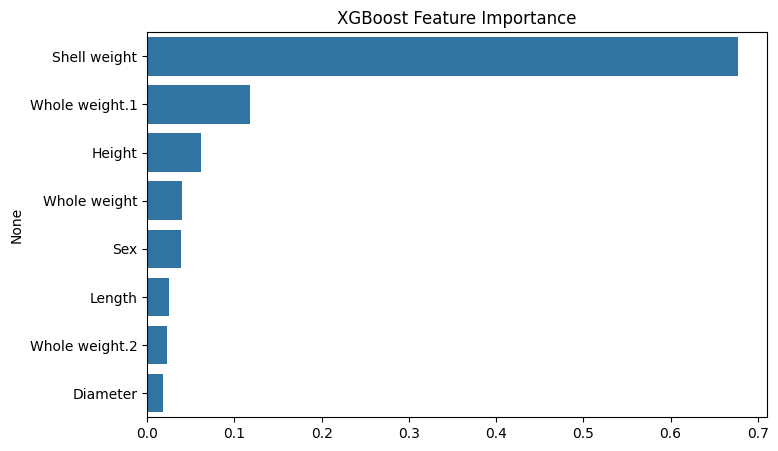

In [ ]:
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index)
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
test_preds = xgb_model.predict(X_test_scaled)
test_preds = np.clip(test_preds, 1, 30)
test_preds = np.round(test_preds).astype(int)

submission = pd.DataFrame({'id': test['id'], 'Rings': test_preds})
submission.to_csv('submission.csv', index=False)

print(f'Submission saved: {len(submission)} rows')
submission.head(10)

Submission saved: 60411 rows


,id,Rings
0,90615,10
1,90616,10
2,90617,10
3,90618,10
4,90619,8
5,90620,9
6,90621,11
7,90622,6
8,90623,8
9,90624,12
